In [13]:
%matplotlib inline
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
from numba import jit
import os
from tqdm import tqdm

## Triangular Lattice Ising Model

**Hamiltonian:** $H = -J \sum_{\langle i,j \rangle} s_i s_j$ where spins $s_i \in \{-1, +1\}$ and the sum runs over the **6 nearest neighbours** of the triangular lattice.

### Lattice embedding
We store the lattice in an $N \times N$ array. Site $(i,j)$ has neighbours:

| Direction | Index |
|-----------|-------|
| Right | $(i,\; j{+}1)$ |
| Left  | $(i,\; j{-}1)$ |
| Upper | $(i{-}1,\; j)$ |
| Lower | $(i{+}1,\; j)$ |
| Upper-left diagonal | $(i{-}1,\; j{-}1)$ |
| Lower-right diagonal | $(i{+}1,\; j{+}1)$ |

All indices are taken mod $N$ (periodic boundary conditions).

### Known exact results
| Model | $T_c$ ($k_B = 1$) |
|-------|-------------------|
| Ferromagnet ($J>0$) | $T_c = 4J / \ln 3 \approx 3.641\,J$ |
| Antiferromagnet ($J<0$) | **No transition** — geometrically frustrated; ground state degeneracy $\sim e^{0.3231 N^2}$ |



In [14]:
#----------------------------------------------------------------------
##  BLOCK OF FUNCTIONS USED IN THE MAIN CODE
#----------------------------------------------------------------------

def initialstate(N):
    '''Generates a random spin configuration for initial condition.'''
    return 2 * np.random.randint(2, size=(N, N)) - 1


@jit(nopython=True)
def mcmove(config, beta, J, N):
    '''
    One full MC sweep (N*N Metropolis trials) on the triangular lattice.

    Each trial:
      1. Pick a random site (a, b).
      2. Compute the energy cost of flipping s_{a,b} using its 6 neighbours.
      3. Accept with the Metropolis criterion.

    Bug fixed vs. existing hexagonal notebooks: neighbours are always
    indexed by (a, b), not by the loop counter (i, j).
    '''
    for _ in range(N * N):
        a = np.random.randint(0, N)
        b = np.random.randint(0, N)
        s = config[a, b]

        # 6 neighbours of the triangular lattice (all mod N for PBC)
        nb = (config[(a + 1) % N, (b + 1) % N]   # lower-right diagonal
            + config[a,           (b + 1) % N]   # right
            + config[(a - 1) % N,  b          ]  # upper
            + config[(a - 1) % N, (b - 1) % N]   # upper-left diagonal
            + config[a,           (b - 1) % N]   # left
            + config[(a + 1) % N,  b          ]) # lower

        cost = 2 * J * s * nb          # delta E = -2 * J * s * sum_neighbours
        if cost < 0:
            s *= -1
        elif rand() < np.exp(-cost * beta):
            s *= -1
        config[a, b] = s
    return config


@jit(nopython=True)
def calcEnergy(config, J, N):
    '''
    Total energy of the configuration.

    Counts exactly 3 bonds per site (right, lower, lower-right diagonal)
    to avoid double-counting:
        3 bonds/site * N^2 sites = 3 N^2 = (6/2) N^2  ✓
    '''
    energy = 0
    for i in range(N):
        for j in range(N):
            S = config[i, j]
            energy += -J * S * (config[i,           (j + 1) % N]   # right
                              + config[(i + 1) % N,  j          ]  # lower
                              + config[(i + 1) % N, (j + 1) % N])  # lower-right diagonal
    return energy


@jit(nopython=True)
def calcMag(config):
    '''Magnetisation of a given configuration.'''
    return np.sum(config)

In [15]:
#----------------------------------------------------------------------
##  VISUALIZATION AND I/O HELPERS
#----------------------------------------------------------------------

def makeFigSaveData(config, N, beta, folder):
    '''
    Save spin configuration as .txt and as a square-grid pcolormesh .png.
    Naming convention matches the existing Ising notebooks.
    '''
    X, Y = np.meshgrid(range(N), range(N))
    plt.figure()
    plt.pcolormesh(X, Y, config, cmap=plt.cm.binary)
    a = plt.gca()
    a.axes.get_xaxis().set_visible(False)
    a.axes.get_yaxis().set_visible(False)
    plt.axis('tight')

    fname = 'beta_' + str(beta) + '_'
    fig_dir = 'figures/' + folder
    if not os.path.isdir(fig_dir):
        os.makedirs(fig_dir)
    plt.savefig('./' + fig_dir + '/' + fname + '.png')
    np.savetxt('./' + folder + '/' + fname + '.txt', config)
    plt.close()


def plotTriangularLattice(config, N, T, title='', folder=None):
    '''
    Render the spin configuration with the correct triangular geometry.

    Physical site positions:
        x_{i,j} = j + i/2,    y_{i,j} = i * sqrt(3)/2
    so rows are offset by half a unit cell, giving a true triangular tiling.
    '''
    xs, ys, cs = [], [], []
    for i in range(N):
        for j in range(N):
            xs.append(j + i * 0.5)
            ys.append(i * np.sqrt(3) / 2)
            cs.append(config[i, j])

    xs = np.array(xs)
    ys = np.array(ys)
    cs = np.array(cs)

    fig, ax = plt.subplots(figsize=(7, 6))
    up   = cs ==  1
    down = cs == -1
    ax.scatter(xs[up],   ys[up],   c='black', s=40, marker='o', label=r'$s=+1$')
    ax.scatter(xs[down], ys[down], c='white', s=40, marker='o',
               edgecolors='black', linewidths=0.6, label=r'$s=-1$')
    ax.set_aspect('equal')
    ax.set_title(f'{title}   T = {T:.3f}   N = {N}', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.axis('off')
    plt.tight_layout()

    if folder is not None:
        os.makedirs(folder, exist_ok=True)
        plt.savefig(os.path.join(folder, f'tri_T{T:.3f}.png'), dpi=120)
    plt.show()
    plt.close()

In [16]:
#----------------------------------------------------------------------
##  SIMULATION PARAMETERS  — edit these
#----------------------------------------------------------------------

nt       = 20          # number of temperature points
N_vals   = [20]        # lattice sizes (N x N)
eqSteps  = 10000       # MC sweeps for equilibration
mcSteps  = 50000       # MC sweeps for measurement

# Set J = +1 for ferromagnet, J = -1 for antiferromagnet
J            = -1
type_folder  = 'Tri_ferro' if J > 0 else 'Tri_antiferro'

# Exact critical temperature for the triangular Ising FERROMAGNET:
#   T_c = 4J / ln(3) ≈ 3.641   (Wannier 1950; no finite-T transition for AFM)
T_c_exact = 4 * abs(J) / np.log(3)   # ≈ 3.641

if J > 0:
    # Bracket the ferromagnetic transition
    T = np.linspace(1.0, 5.5, nt)
else:
    # Antiferromagnet: no transition; scan a wide range to show the
    # broad Schottky-like peak in C and the absence of ordering
    T = np.linspace(0.5, 6.0, nt)

E, M, C, X = np.zeros(nt), np.zeros(nt), np.zeros(nt), np.zeros(nt)

In [17]:
# Warm up numba JIT (compile on a tiny lattice so it does not bias timing)
_s = initialstate(4)
_s = mcmove(_s, 1.0, J, 4)
_ = calcEnergy(_s, J, 4)
_ = calcMag(_s)
print('JIT warm-up complete.')

JIT warm-up complete.


In [18]:
#----------------------------------------------------------------------
##  MAIN SIMULATION LOOP
#----------------------------------------------------------------------

for N in N_vals:
    folder = type_folder + '/data_N_' + str(N)
    if not os.path.isdir(folder):
        os.makedirs(folder)

    n1 = 1.0 / mcSteps
    n2 = 1.0 / (mcSteps * mcSteps)

    print(f'\n=== N = {N},  J = {J} ===')
    for tt in tqdm(range(nt)):
        beta  = 1.0 / T[tt]
        fname = 'beta_' + str(beta) + '_'

        # Load saved config if available, else start fresh
        if os.path.isfile('./' + folder + '/' + fname + '.txt'):
            config = np.loadtxt('./' + folder + '/' + fname + '.txt').astype(np.int64)
        else:
            config = initialstate(N)

        # --- Equilibration ---
        for _ in range(eqSteps):
            config = mcmove(config, beta, J, N)

        # --- Measurement ---
        E1 = E2 = M1 = M2 = 0
        for _ in range(mcSteps):
            config = mcmove(config, beta, J, N)

            Ene = calcEnergy(config, J, N)
            Mag = calcMag(config)

            E1 += Ene
            E2 += Ene * Ene
            M1 += abs(Mag)          # |M| avoids cancellation from symmetry flips
            M2 += Mag * Mag

        Ns = N * N
        E[tt] = n1 * E1 / Ns
        M[tt] = n1 * M1 / Ns
        C[tt] = (n1 * E2 - n2 * E1 * E1) * beta**2 / Ns
        X[tt] = (n1 * M2 - n2 * M1 * M1) * beta / Ns

        makeFigSaveData(config, N, beta, folder)

print('\nSimulation complete.')


=== N = 20,  J = -1 ===


100%|██████████| 20/20 [00:26<00:00,  1.30s/it]


Simulation complete.


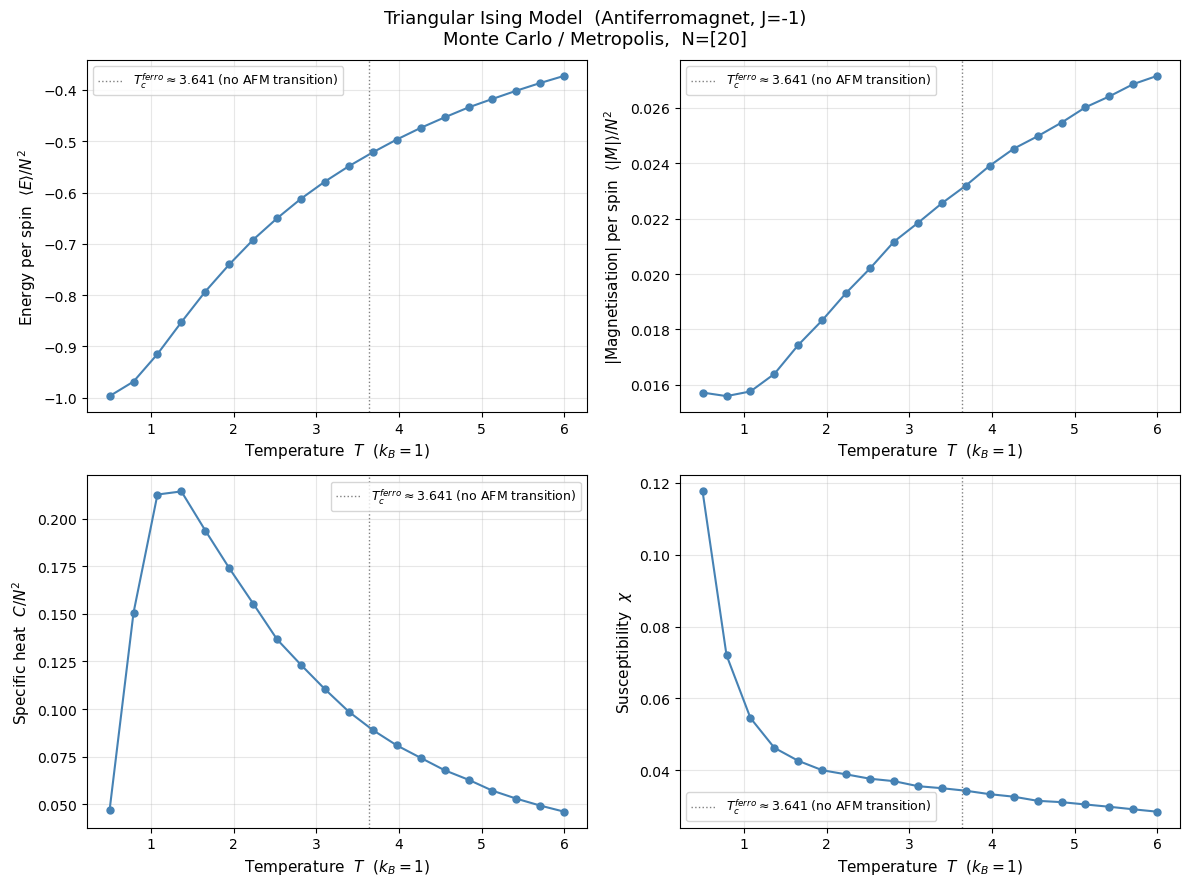

In [19]:
#----------------------------------------------------------------------
##  PLOT THERMODYNAMIC OBSERVABLES
#----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    f'Triangular Ising Model  ({"Ferromagnet" if J > 0 else "Antiferromagnet"}, J={J})\n'
    f'Monte Carlo / Metropolis,  N={N_vals}',
    fontsize=13
)

plot_data = [
    (axes[0, 0], E, r'Energy per spin  $\langle E \rangle / N^2$'),
    (axes[0, 1], M, r'|Magnetisation| per spin  $\langle |M| \rangle / N^2$'),
    (axes[1, 0], C, r'Specific heat  $C / N^2$'),
    (axes[1, 1], X, r'Susceptibility  $\chi$'),
]

for ax, obs, ylabel in plot_data:
    ax.plot(T, obs, 'o-', ms=5, color='steelblue')
    ax.set_xlabel(r'Temperature  $T$  ($k_B = 1$)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(alpha=0.3)

    if J > 0:
        ax.axvline(T_c_exact, color='red', linestyle='--', linewidth=1.2,
                   label=rf'$T_c = 4J/\ln 3 \approx {T_c_exact:.3f}$')
        ax.legend(fontsize=9)
    else:
        ax.axvline(T_c_exact, color='gray', linestyle=':', linewidth=1,
                   label=rf'$T_c^{{ferro}} \approx {T_c_exact:.3f}$ (no AFM transition)')
        ax.legend(fontsize=9)

plt.tight_layout()
fig_dir = 'figures/' + type_folder
os.makedirs(fig_dir, exist_ok=True)
plt.savefig(fig_dir + '/observables.png', dpi=150)
plt.show()


--- T = 0.7895 ---


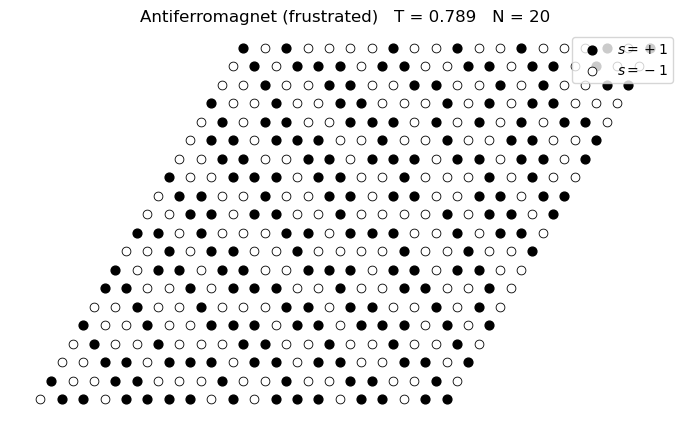


--- T = 1.9474 ---


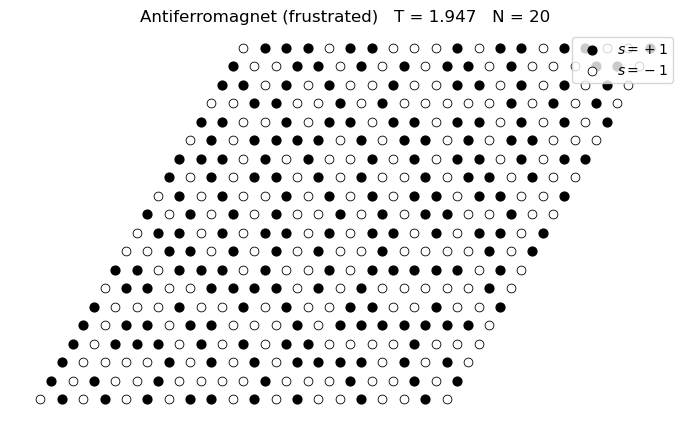


--- T = 5.1316 ---


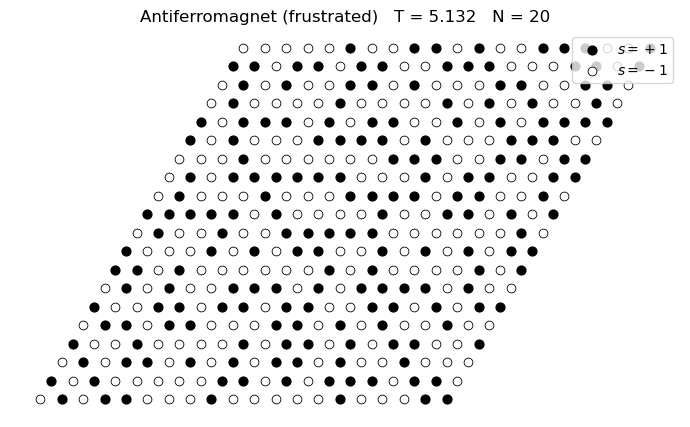

In [20]:
#----------------------------------------------------------------------
##  VISUALIZE SPIN CONFIGURATIONS
##  Show three temperatures: low / near-critical / high
#----------------------------------------------------------------------

N_vis   = N_vals[0]

if J > 0:
    T_show = [T_c_exact * 0.5, T_c_exact, T_c_exact * 1.4]
else:
    T_show = [0.8, 2.0, 5.0]

for T_target in T_show:
    tt       = np.argmin(np.abs(T - T_target))
    T_actual = T[tt]
    beta_t   = 1.0 / T_actual
    fname    = 'beta_' + str(beta_t) + '_'
    fpath    = type_folder + '/data_N_' + str(N_vis) + '/' + fname + '.txt'

    if os.path.isfile(fpath):
        config = np.loadtxt(fpath).astype(np.int64)
        print(f'\n--- T = {T_actual:.4f} ---')
        plotTriangularLattice(
            config, N_vis, T_actual,
            title='Ferromagnet' if J > 0 else 'Antiferromagnet (frustrated)',
            folder='figures/' + type_folder
        )
    else:
        print(f'Config for T={T_actual:.4f} not found — run main loop first.')

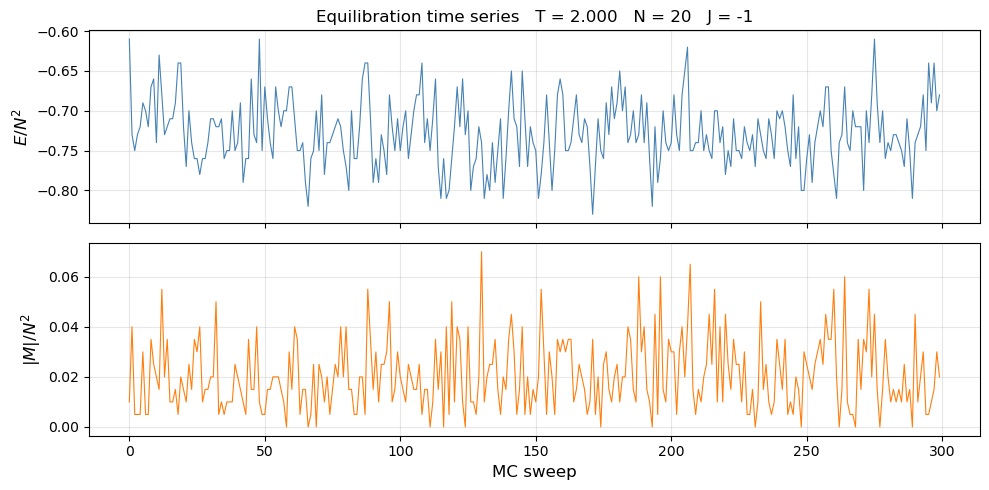

In [21]:
#----------------------------------------------------------------------
##  EQUILIBRATION CHECK — energy time series near T_c
#----------------------------------------------------------------------

T_chk    = T_c_exact if J > 0 else 2.0
N_chk    = N_vals[0]
beta_chk = 1.0 / T_chk
n_rec    = 300

config_chk = initialstate(N_chk)
E_ts = np.zeros(n_rec)
M_ts = np.zeros(n_rec)

for step in range(n_rec):
    config_chk = mcmove(config_chk, beta_chk, J, N_chk)
    E_ts[step]  = calcEnergy(config_chk, J, N_chk) / N_chk**2
    M_ts[step]  = abs(calcMag(config_chk)) / N_chk**2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.plot(E_ts, lw=0.8, color='steelblue')
ax1.set_ylabel(r'$E / N^2$', fontsize=12)
ax1.set_title(
    f'Equilibration time series   T = {T_chk:.3f}   N = {N_chk}   J = {J}',
    fontsize=12
)
ax1.grid(alpha=0.3)

ax2.plot(M_ts, lw=0.8, color='C1')
ax2.set_ylabel(r'$|M| / N^2$', fontsize=12)
ax2.set_xlabel('MC sweep', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/' + type_folder + '/equilibration.png', dpi=120)
plt.show()

In [22]:
#----------------------------------------------------------------------
##  FINITE-SIZE SCALING  (only meaningful for the ferromagnet)
##  Run multiple N values above and look for the C peak shifting toward T_c.
#----------------------------------------------------------------------

if J > 0:
    N_fss    = [10, 20, 30]    # lattice sizes for FSS
    nt_fss   = 15
    eq_fss   = 5000
    mc_fss   = 20000
    T_fss    = np.linspace(2.5, 4.5, nt_fss)

    C_fss = {}   # specific heat curves for each N

    for N in N_fss:
        folder_fss = type_folder + '/fss_N_' + str(N)
        os.makedirs(folder_fss, exist_ok=True)
        C_N = np.zeros(nt_fss)
        print(f'\nFSS: N = {N}')
        for tt in tqdm(range(nt_fss)):
            beta  = 1.0 / T_fss[tt]
            config = initialstate(N)
            for _ in range(eq_fss):
                config = mcmove(config, beta, J, N)
            E1 = E2 = 0
            n1_f = 1.0 / mc_fss
            n2_f = 1.0 / (mc_fss * mc_fss)
            for _ in range(mc_fss):
                config = mcmove(config, beta, J, N)
                Ene = calcEnergy(config, J, N)
                E1 += Ene
                E2 += Ene * Ene
            C_N[tt] = (n1_f * E2 - n2_f * E1 * E1) * beta**2 / (N * N)
        C_fss[N] = C_N

    plt.figure(figsize=(8, 5))
    for N, C_N in C_fss.items():
        plt.plot(T_fss, C_N, 'o-', ms=4, label=f'N={N}')
    plt.axvline(T_c_exact, color='red', linestyle='--',
                label=rf'$T_c = {T_c_exact:.3f}$')
    plt.xlabel(r'Temperature $T$', fontsize=12)
    plt.ylabel(r'Specific heat $C / N^2$', fontsize=12)
    plt.title('Finite-size scaling of specific heat — Triangular Ising Ferromagnet', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/' + type_folder + '/finite_size_scaling.png', dpi=150)
    plt.show()
else:
    print('Finite-size scaling cell is for the ferromagnet only (J > 0).')
    print('For the AFM, the broad Schottky peak does not sharpen with N — confirming no true transition.')

Finite-size scaling cell is for the ferromagnet only (J > 0).
For the AFM, the broad Schottky peak does not sharpen with N — confirming no true transition.
